In [1]:
## 2026.08.20 CODEX PDAC counterpart of CODEX_hcc/HCC_histology_derived_niche_index.ipynb
##            TLS / SRI / TNI from StarDist Level-2 softmax on s1167 matched nuclei
## 2026.08.27 Shared engine: code/Hist2Pheno_pkg/histology_niche_index.py
##            PDAC paths/clinical: code/CODEX_pdac/pdac_histology_derived_niche_index.py
## 2026.08.28 Train Hist2Pheno on 278 annotated PDAC cores, see prediction results

## 1. Load predicted cell-type probabilities (soft abundance)

This notebook is the **CODEX PDAC (s1167)** analog of `CODEX_hcc/HCC_histology_derived_niche_index.ipynb`.

It uses pooled StarDist matched-AUROC predictions under `s1167/result_all_spatial_pdac/stardist/{ACQUISITION_ID}/`.

| Source | Predictions | Coordinates |
|--------|-------------|-------------|
| **Matched AUROC** | `stardist/{acq}/validation_external_stardist_matched_AUROC.csv` | `s1167/{acq}/{acq}_matched_features_stardist.h5ad` (`obsm['spatial_HE']`) |

**Demo core:** `Charvill-94_c001_v001_r001_reg001`. Cohort = annotated PDAC cores (278).

There is **no Response** field. Clinical groups are **coverslip** and **SAMPLE_LABEL**.

Level-2: Epithelial cells, Fibroblasts, Cytotoxic/Helper T, Tregs, Macrophages, Neutrophils, DC, B/Plasma, Lymphatic Endothelial. TNI myeloid compartment = **Macrophages** (no M2-like class).

Shared TLS / SRI / TNI math: `Hist2Pheno_pkg/histology_niche_index.py` (`OrganNicheConfig` for `codex_pdac`).  
This notebook keeps PDAC paths and clinical loaders in `pdac_histology_derived_niche_index.py`. Spatial maps still reuse Xenium `plot_ari_fri_*` helpers with SRI/TNI column names.


In [2]:
import sys
import importlib
from pathlib import Path

import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/lingyu/ssd2/Python/"
_repo = Path(f"{path}Hist2Pheno/code")
for _p in (_repo / "Hist2Pheno_pkg", _repo / "Xenium_lung", _repo / "CODEX_pdac"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import histology_niche_index as hni
importlib.reload(hni)
import s1167_histology_derived_niche_index as s1167_ni
importlib.reload(s1167_ni)
import pdac_histology_derived_niche_index as pdac_ni
importlib.reload(pdac_ni)

DATA_ROOT = pdac_ni.DEFAULT_DATA_ROOT
CASES_ROOT = pdac_ni.DEFAULT_CASES_ROOT
STARDIST_ROOT = pdac_ni.DEFAULT_STARDIST_ROOT
OUT_DIR = DATA_ROOT / "result_all_spatial_pdac" / "niche_index_pdac"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("STARDIST :", STARDIST_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("shared   :", hni.__file__)
print("organ    :", pdac_ni.cfg().pan_organ, pdac_ni.cfg().tls_t)


DATA_ROOT: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167
STARDIST : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist
OUT_DIR  : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/niche_index_pdac
shared   : /home/lingyu/ssd2/Python/Hist2Pheno/code/Hist2Pheno_pkg/histology_niche_index.py
organ    : codex_pdac ('Cytotoxic T cells', 'Helper T cells', 'Tregs')


In [3]:
SAMPLE = pdac_ni.DEFAULT_DEMO_SAMPLE
RADIUS_UM = pdac_ni.DEFAULT_SPATIAL_RADIUS_UM
UM_PER_PX = pdac_ni.DEFAULT_UM_PER_HE_PIXEL

clinical = pdac_ni.load_s1167_clinical_info()
annotation = pdac_ni.load_s1167_annotation()
ALL_SAMPLES = pdac_ni.discover_s1167_spatial_samples(clinical, require_h5ad=True)
paths = pdac_ni.s1167_spatial_paths(SAMPLE)

print(f"Demo core: {SAMPLE}")
print(f"Annotated cores with AUROC+h5ad: {len(ALL_SAMPLES)}")
print("AUROC:", paths.auroc_csv)
print("h5ad :", paths.stardist_h5ad)
print(f"Spatial radius: {RADIUS_UM} μm | μm/px={UM_PER_PX}")
display(pdac_ni.index_formula_table())
display(annotation)
display(clinical.head())


Clinical rows: 278 (cohort=PDAC)


,ACQUISITION_ID,coverslip,SAMPLE_LABEL,SAMPLE_ID,tissue_type
0,Charvill-94_c001_v001_r001_reg002,c001,TA-237,NaN,Pancreas TMA
1,Charvill-94_c001_v001_r001_reg003,c001,TA-237,NaN,Pancreas TMA
2,Charvill-94_c001_v001_r001_reg012,c001,TA-237,NaN,Pancreas TMA
3,Charvill-94_c001_v001_r001_reg014,c001,TA-237,NaN,Pancreas TMA
4,Charvill-94_c001_v001_r001_reg026,c001,TA-237,NaN,Pancreas TMA
5,Charvill-94_c001_v001_r001_reg029,c001,TA-237,NaN,Pancreas TMA
6,Charvill-94_c001_v001_r001_reg037,c001,TA-237,NaN,Pancreas TMA
7,Charvill-94_c001_v001_r001_reg047,c001,TA-237,NaN,Pancreas TMA
8,Charvill-94_c001_v001_r001_reg058,c001,TA-237,NaN,Pancreas TMA
9,Charvill-94_c001_v001_r001_reg065,c001,TA-237,NaN,Pancreas TMA



coverslip


coverslip
c001    148
c003    130
Name: count, dtype: int64


SAMPLE_LABEL


SAMPLE_LABEL
TA-237    148
TA-256    130
Name: count, dtype: int64

Demo core: Charvill-94_c001_v001_r001_reg001
Annotated cores with AUROC+h5ad: 278
AUROC: /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/result_all_spatial_pdac/stardist/Charvill-94_c001_v001_r001_reg001/validation_external_stardist_matched_AUROC.csv
h5ad : /nobackup2/users/lingyu/Python/Hist2Pheno/data/CODEX/HCC/Michael_data_transfer/s1167/Charvill-94_c001_v001_r001_reg001/Charvill-94_c001_v001_r001_reg001_matched_features_stardist.h5ad
Spatial radius: 55.0 μm | μm/px=0.5


,index,hcc_analog,formula
0,TLS,TLS,sum(B cells+ Cytotoxic T cells+ Helper T cells...
1,TLS_spatial,TLS_spatial,(B_local × T_local × DC_local)^(1/3) within ra...
2,SRI_ratio,SRI_ratio,Fibroblasts / Epithelial cells
3,SRI_spatial,SRI_spatial,Fib_local / Epi_local within radius R μm
4,TNI_ratio,TNI_ratio,(Fibroblasts + Macrophages + Lymphatic Endothe...
5,TNI_spatial,TNI_spatial,(Fib_local × myeloid_local × Endo_local)^(1/3)...


,cohort,celltype_level2,celltype_level1,celltype_level0
0,Pancreas TMA,Epithelial cells,Epithelial,Epithelial
1,Pancreas TMA,Fibroblasts,Stromal,Stromal
2,Pancreas TMA,Cytotoxic T cells,T cells,Immune
3,Pancreas TMA,Helper T cells,T cells,Immune
4,Pancreas TMA,Tregs,T cells,Immune
5,Pancreas TMA,Macrophages,Myeloid,Immune
6,Pancreas TMA,Neutrophils,Myeloid,Immune
7,Pancreas TMA,Dendritic cells,Myeloid,Immune
8,Pancreas TMA,B cells,B cells,Immune
9,Pancreas TMA,Plasma cells,B cells,Immune


,ACQUISITION_ID,SAMPLE_LABEL,SAMPLE_ID,tissue_type,tissue_subtype,diagnosis,tma_position,site,size,mitotic_rate,mutation_status,risk,primary,PATIENT_ID,species,treatment,prefix,cohort,tissue_type_filled,coverslip
0,Charvill-94_c001_v001_r001_reg002,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA,c001
1,Charvill-94_c001_v001_r001_reg003,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA,c001
2,Charvill-94_c001_v001_r001_reg012,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA,c001
3,Charvill-94_c001_v001_r001_reg014,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA,c001
4,Charvill-94_c001_v001_r001_reg026,TA-237,NaN,Pancreas TMA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Charvill-94_c001,Pancreas TMA,Pancreas TMA,c001


In [4]:
df, class_names, probs = pdac_ni.load_stardist_auroc_csv(
    paths.auroc_csv, paths.class_names_csv,
)
missing = pdac_ni.missing_index_cell_types(class_names)
print(f"{SAMPLE}: {len(df):,} cells, {len(class_names)} classes")
print("classes:", class_names)
if missing:
    raise KeyError(f"Missing index compartments in class_names: {missing}")
df.head(3)


Charvill-94_c001_v001_r001_reg001: 5,981 cells, 11 classes
classes: ['B cells', 'Cytotoxic T cells', 'Dendritic cells', 'Epithelial cells', 'Fibroblasts', 'Helper T cells', 'Lymphatic Endothelial cells', 'Macrophages', 'Neutrophils', 'Plasma cells', 'Tregs']


,cell_id,ground_truth_final_CT,predict_stardist_final_CT,ground_truth_idx,predict_stardist_idx,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,prob_10
0,1,Fibroblasts,Fibroblasts,4,4,0.012319,0.125027,0.020550,0.064539,0.376188,0.037973,0.054730,0.027640,0.023105,0.161245,0.096684
1,2,Macrophages,Cytotoxic T cells,7,1,0.025374,0.297852,0.003296,0.096416,0.037509,0.091508,0.113162,0.025548,0.055434,0.078462,0.175441
2,3,Cytotoxic T cells,Cytotoxic T cells,1,1,0.018681,0.296818,0.002255,0.120748,0.036220,0.030211,0.051497,0.009131,0.011220,0.292787,0.130432


## 2. Compute histology-derived indices (abundance)

PDAC indices use **Level-2 softmax** (soft abundance per nucleus).

| Index | Formula | HCC analog |
|-------|---------|------------|
| **TLS** | B + Cytotoxic T + Helper T + Tregs + DC | TLS |
| **SRI_ratio** | Fibroblasts / Epithelial cells | SRI |
| **TNI_ratio** | (Fibroblasts + Macrophages + Lymphatic Endothelial) / epithelium | TNI |

**Read order:** SRI → TNI → TLS. High SRI alone = epithelial mass replaced by stroma. High SRI **and** TNI = active CAF / macrophage / endothelial niche.


In [5]:
df_idx = pdac_ni.add_abundance_indices(df, probs, class_names)
sample_summary = pdac_ni.summarize_indices_by_sample(df_idx, SAMPLE)
display(sample_summary)
df_idx.filter(regex="^(cell_id|predict_stardist|idx_)").head()


,Sample,n_cells,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,Charvill-94_c001_v001_r001_reg001,5981,0.531748,1.817411,4.961284


,cell_id,predict_stardist_final_CT,predict_stardist_idx,idx_TLS,idx_SRI_ratio,idx_TNI_ratio
0,1,Fibroblasts,4,0.292553,5.828836,7.105113
1,2,Cytotoxic T cells,1,0.593470,0.389033,1.827701
2,3,Cytotoxic T cells,1,0.478397,0.299961,0.802069
3,4,Cytotoxic T cells,1,0.608876,0.607123,2.043811
4,5,Cytotoxic T cells,1,0.635320,1.961733,15.306591


## 3. Spatial TLS (B / T / DC co-localization)

**TLS_spatial** = `(B_local × T_local × DC_local)^(1/3)` within radius **R μm**.

Cyan points = `tls_candidate` (top 5% `idx_TLS_spatial` on this core).


In [6]:
df_spatial, class_names_sp, probs_sp, coords, paths_sp, um_px = pdac_ni.load_sample_with_spatial_indices(
    SAMPLE, radius_um=RADIUS_UM, um_per_pixel=UM_PER_PX,
)
print(f"{SAMPLE} | μm/px={um_px:.4f} | R={RADIUS_UM} μm | n={len(df_spatial):,}")
print("TLS hotspot:", pdac_ni.summarize_tls_hotspots(df_spatial))
cols = [
    "cell_id", "coord_x", "coord_y", "idx_TLS", "idx_TLS_spatial",
    "idx_SRI_spatial", "idx_TNI_spatial", "tls_candidate", "sri_candidate", "tni_candidate",
]
display(
    df_spatial.loc[df_spatial["tls_candidate"], cols]
    .sort_values("idx_TLS_spatial", ascending=False)
    .head(5)
)


Charvill-94_c001_v001_r001_reg001 | μm/px=0.5000 | R=55.0 μm | n=5,981
TLS hotspot: {'n_cells_total': 5981, 'n_candidate_cells': 300, 'fraction_candidate': 0.05015883631499749, 'max_tls_spatial': 0.09758622610576013, 'mean_tls_spatial_candidate': 0.07602062217050647, 'centroid_x': 1564.7666666666667, 'centroid_y': 1809.4433333333334}


,cell_id,coord_x,coord_y,idx_TLS,idx_TLS_spatial,idx_SRI_spatial,idx_TNI_spatial,tls_candidate,sri_candidate,tni_candidate
1008,1016,1376.0,1147.0,0.685139,0.097586,0.950301,0.871947,True,False,False
2162,2179,1435.0,1598.0,0.456966,0.095069,0.363587,0.541150,True,False,False
2105,2121,1429.0,1579.0,0.636577,0.094566,0.336849,0.498293,True,False,False
2157,2174,1453.0,1598.0,0.302910,0.094373,0.390755,0.562834,True,False,False
2082,2098,1441.0,1573.0,0.827486,0.093608,0.306876,0.448585,True,False,False


(<Figure size 1800x500 with 4 Axes>,
 array([<Axes: title={'center': 'Charvill-94_c001_v001_r001_reg001 (CODEX PDAC): Abundance TLS (idx_TLS)'}>,
        <Axes: title={'center': 'Charvill-94_c001_v001_r001_reg001 (CODEX PDAC): Spatial TLS (R=55 μm)'}>],
       dtype=object))

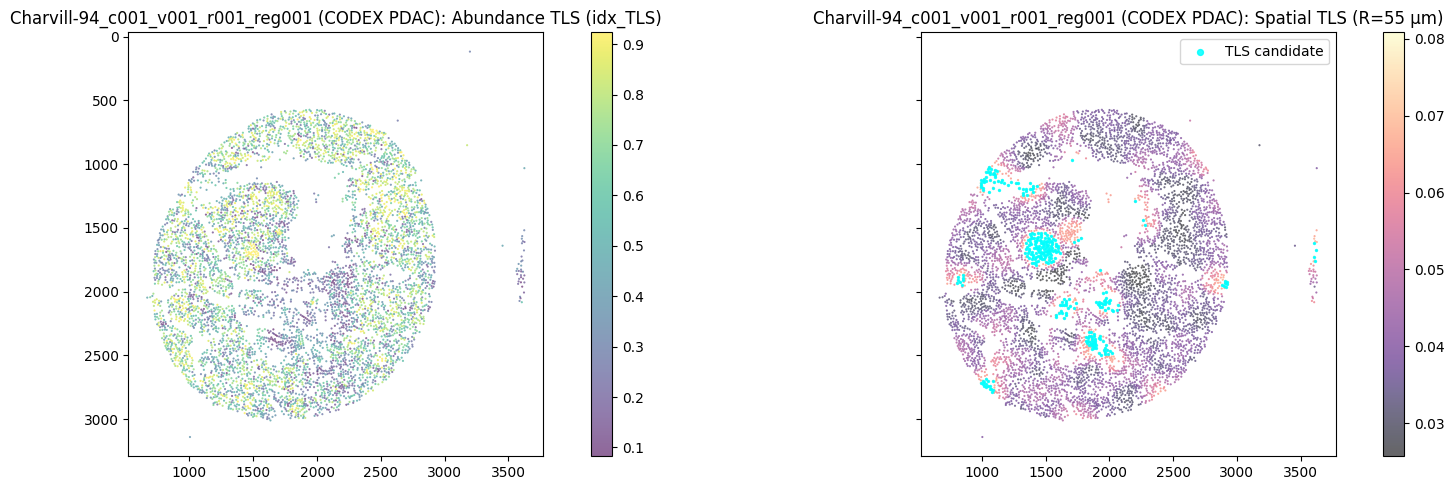

In [15]:
pdac_ni.plot_tls_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX PDAC)",
    radius_um=RADIUS_UM, figsize=(18.0 * 1.0, 5.0 * 1.0), dpi=150,
)


## 4. Spatial SRI / TNI (stromal remodeling → active TME niche)

1. **SRI** — local fibroblasts vs epithelium.
2. **TNI** — co-localized fibroblasts × macrophages × endothelium / epithelium.
3. **TLS** — adaptive immune aggregate.

High SRI **and** high TNI → active immunosuppressive / angiogenic microenvironment.


,cell_id,coord_x,coord_y,idx_SRI_ratio,idx_SRI_spatial,idx_TNI_ratio,idx_TNI_spatial,sri_candidate,tni_candidate
3298,3319,1878.0,1971.0,20.804227,19.668365,42.722693,13.237278,True,True
3306,3327,1848.0,1974.0,33.407789,20.021792,81.270429,13.119175,True,True
3232,3253,1850.0,1946.0,24.850818,18.583635,89.861729,12.444371,True,True
3161,3182,1811.0,1926.0,13.953664,18.969979,24.683246,11.942405,True,True
3146,3167,1877.0,1920.0,64.458105,17.024813,209.313881,11.635683,True,True


Active TME-niche cells (SRI ∩ TNI hotspot): 271 (4.53% of tissue)


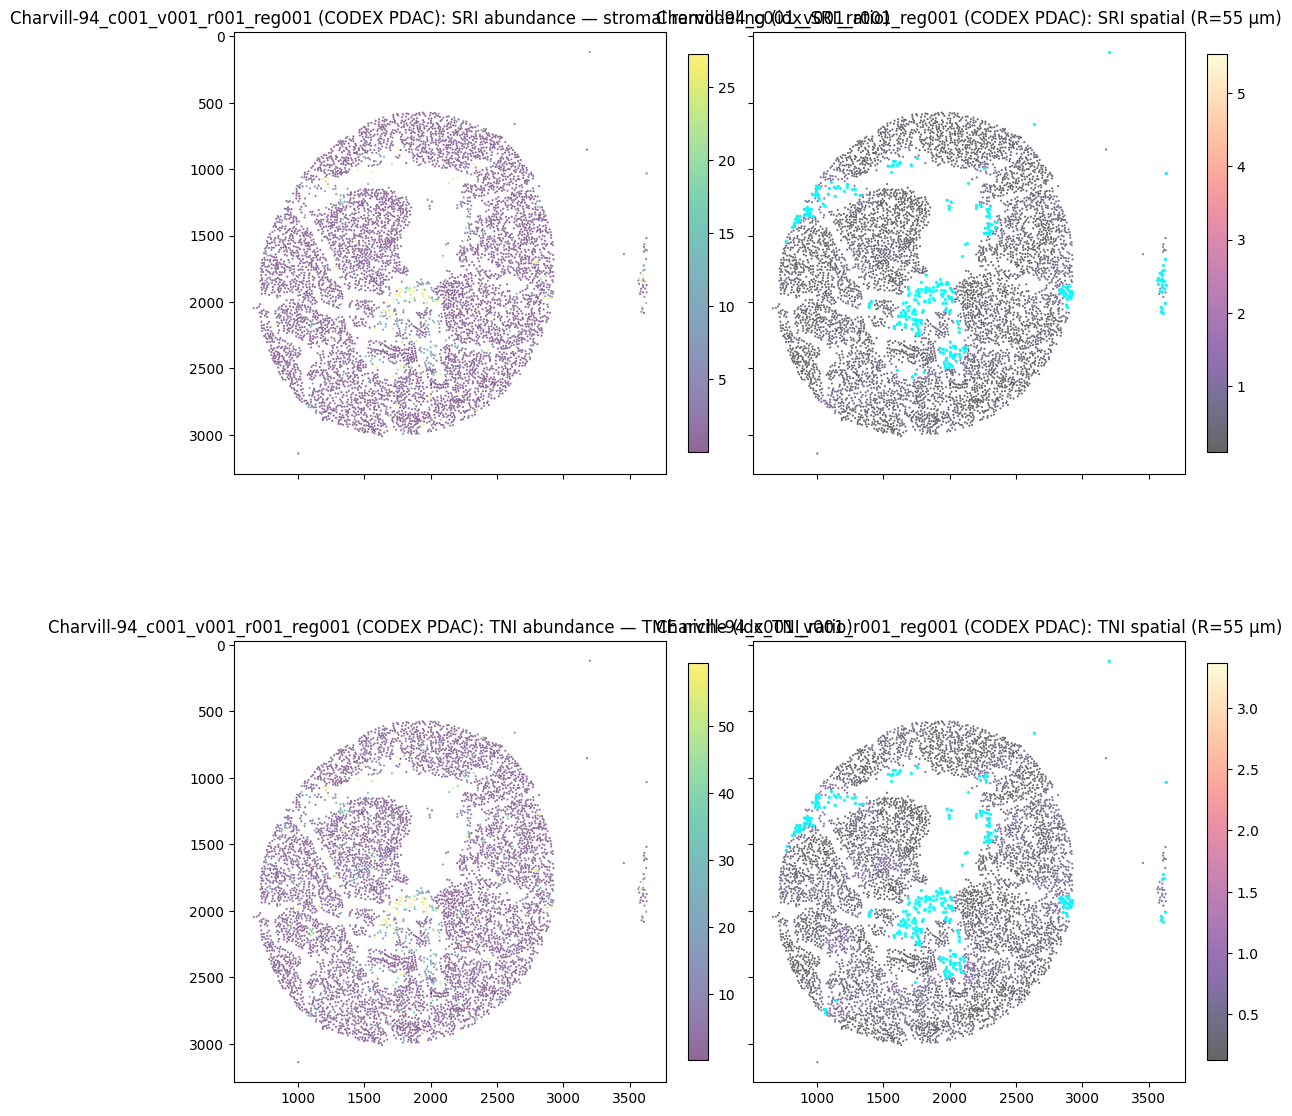

In [8]:
display(
    df_spatial[
        ["cell_id", "coord_x", "coord_y", "idx_SRI_ratio", "idx_SRI_spatial",
         "idx_TNI_ratio", "idx_TNI_spatial", "sri_candidate", "tni_candidate"]
    ]
    .sort_values("idx_TNI_spatial", ascending=False)
    .head(5)
)
pdac_ni.plot_sri_tni_abundance_vs_spatial(
    df_spatial, f"{SAMPLE} (CODEX PDAC)",
    radius_um=RADIUS_UM, figsize=(9.0 * 1.2, 5 * 1.2), dpi=150,
)
active = df_spatial["sri_candidate"] & df_spatial["tni_candidate"]
print(
    f"Active TME-niche cells (SRI ∩ TNI hotspot): {int(active.sum())} "
    f"({100 * active.mean():.2f}% of tissue)"
)


## 5. Hierarchical SRI → TNI (within-core quadrants)

Biological hierarchy: **Normal (Q1) → SRI↑ remodeling (Q2) → SRI↑+TNI↑ active niche (Q4)**.

Cross-core clinical comparisons use **Global Q4** and **active niche burden** in §6.


,quadrant,label,n_cells,percent
0,Q1,Normal / epithelial-dominant,5652,94.499248
1,Q2,Stromal remodeling (epithelial replacement by ...,29,0.484869
2,Q3,Immune / angiogenic activation without extensi...,29,0.484869
3,Q4,Active TME niche (fibroblasts + myeloid + endo...,271,4.531015


Spearman rho=0.934, p=0 | Q4 (active TME niche)=4.53%


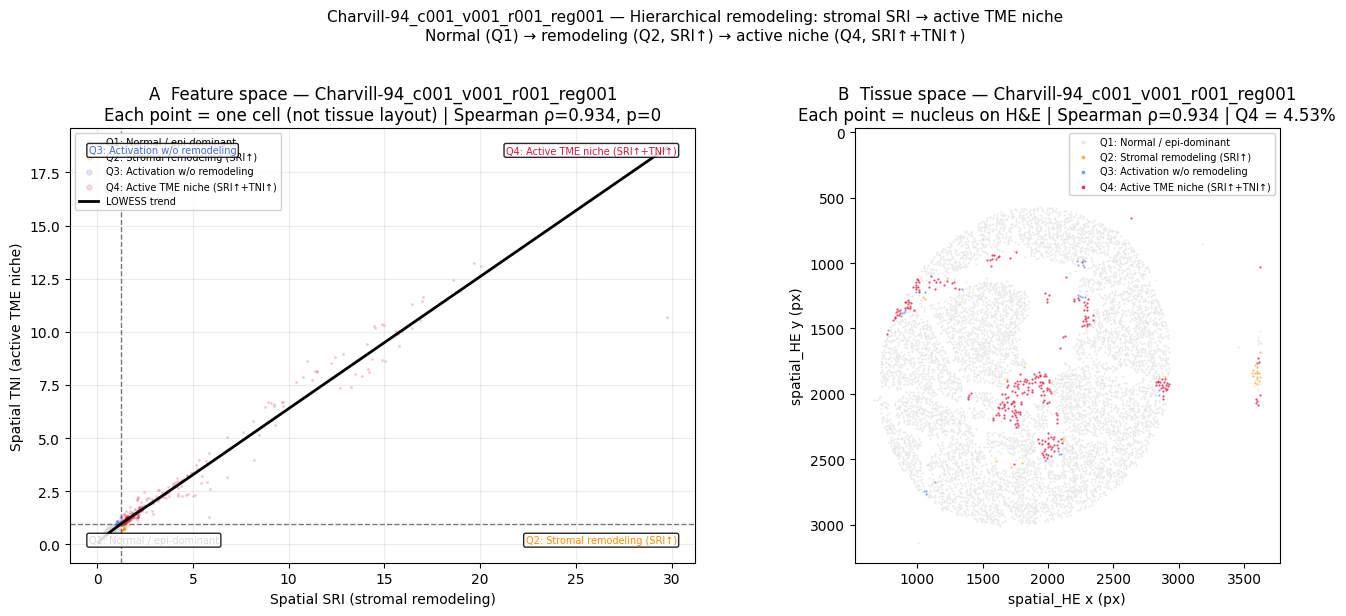

In [9]:
sri_tni_result = pdac_ni.analyze_sri_tni_relationship(
    df_spatial, SAMPLE, plot=True, plot_layout="combined",
    figsize=(14, 6), figsize_scatter=(5.5, 5.5), figsize_spatial=(8.0, 8.0), dpi=150,
)
display(sri_tni_result["quadrant_table"])
print(
    f"Spearman rho={sri_tni_result['Spearman_rho']:.3f}, p={sri_tni_result['Spearman_p']:.2g} | "
    f"Q4 (active TME niche)={sri_tni_result['Q4_percent']:.2f}%"
)


## 6. Cohort: TME niche burden vs coverslip / SAMPLE_LABEL

| Metric | Definition |
|--------|------------|
| **Global Q4 %** | % cells with SRI and TNI ≥ cohort-pooled 95th percentiles |
| **Active niche burden** | `mean(√(SRI_i × TNI_i))` over matched nuclei |

Clinical groups: **coverslip**, **SAMPLE_LABEL** (`pan_organ="codex_pdac"`).

Set `QUICK_VALIDATE = True` to load a few cores first. Full 278-core run is slow.


In [10]:
import importlib
importlib.reload(pdac_ni)

QUICK_VALIDATE = True
COHORT_SAMPLES = ALL_SAMPLES[:6] if QUICK_VALIDATE else ALL_SAMPLES
print(f"Loading {len(COHORT_SAMPLES)} cores (QUICK_VALIDATE={QUICK_VALIDATE})")

sample_dict = pdac_ni.build_sample_dict(
    COHORT_SAMPLES, radius_um=RADIUS_UM, um_per_pixel=UM_PER_PX,
)
sri_tni_batch, cohort_meta = pdac_ni.batch_analyze_sri_tni_cohort(sample_dict)
print(
    f"Cohort global cutoffs (p{cohort_meta['percentile']:.0f}, "
    f"n={cohort_meta['n_cells_pooled']:,} cells): "
    f"SRI={cohort_meta['sri_threshold_global']:.4f}, "
    f"TNI={cohort_meta['tni_threshold_global']:.4f}"
)
display(
    sri_tni_batch.sort_values("active_niche_burden", ascending=False)[
        ["Sample", "n_cells", "Q4_global_percent", "active_niche_burden",
         "SRI_median", "TNI_median", "Spearman_rho"]
    ].head()
)


Loading 6 cores (QUICK_VALIDATE=True)
  loaded Charvill-94_c001_v001_r001_reg001: 5,981 cells
  loaded Charvill-94_c001_v001_r001_reg002: 4,736 cells
  loaded Charvill-94_c001_v001_r001_reg003: 4,047 cells
  loaded Charvill-94_c001_v001_r001_reg004: 3,620 cells
  loaded Charvill-94_c001_v001_r001_reg005: 8,904 cells
  loaded Charvill-94_c001_v001_r001_reg006: 4,777 cells
Cohort global cutoffs (p95, n=32,065 cells): SRI=15.5914, TNI=8.2321


,Sample,n_cells,Q4_global_percent,active_niche_burden,SRI_median,TNI_median,Spearman_rho
3,Charvill-94_c001_v001_r001_reg004,3620,15.966851,6.504064,2.843519,1.610751,0.975329
5,Charvill-94_c001_v001_r001_reg006,4777,5.547415,4.066725,2.373976,1.490638,0.942608
2,Charvill-94_c001_v001_r001_reg003,4047,7.536447,3.723500,0.918130,0.622046,0.974034
1,Charvill-94_c001_v001_r001_reg002,4736,0.042230,1.487096,1.365023,0.698095,0.950472
4,Charvill-94_c001_v001_r001_reg005,8904,1.201707,0.842646,0.273552,0.266179,0.967368


=== Global Q4 % ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,neg_log10_p
0,coverslip,Q4_global_percent,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
1,SAMPLE_LABEL,Q4_global_percent,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN


=== Active TME niche burden ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,neg_log10_p
0,coverslip,active_niche_burden,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
1,SAMPLE_LABEL,active_niche_burden,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN


(<Figure size 1000x400 with 2 Axes>,
 array([[<Axes: title={'center': 'coverslip'}, ylabel='Active TME niche burden'>,
         <Axes: title={'center': 'SAMPLE_LABEL'}>]], dtype=object))

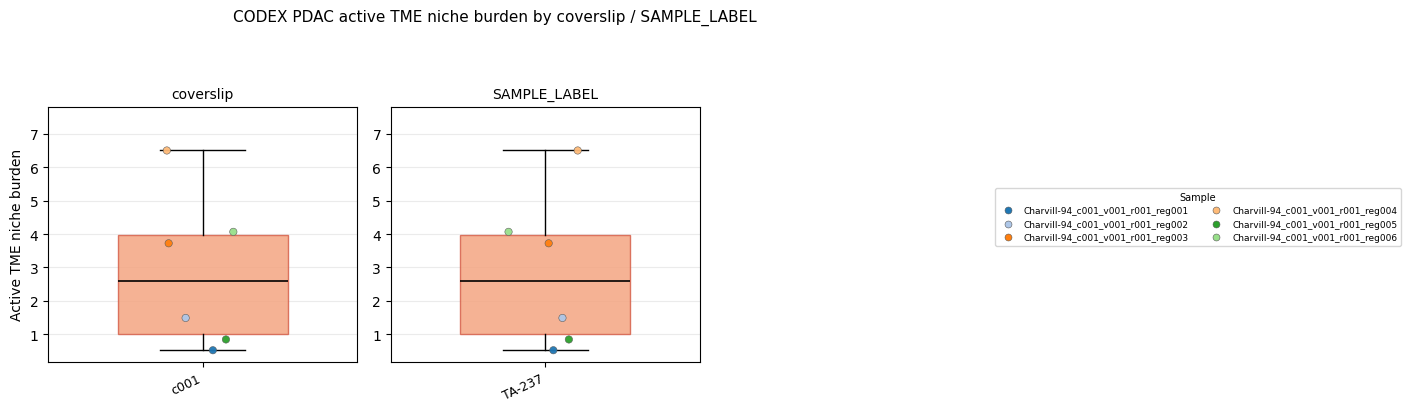

In [11]:
sri_tni_clinical = pdac_ni.merge_batch_with_clinical(sri_tni_batch, clinical)
q4_stats = pdac_ni.test_clinical_groups(
    sri_tni_clinical, metric_col="Q4_global_percent", alternative="two-sided",
)
burden_stats = pdac_ni.test_clinical_groups(
    sri_tni_clinical, metric_col="active_niche_burden", alternative="two-sided",
)
print("=== Global Q4 % ===")
display(q4_stats)
print("=== Active TME niche burden ===")
display(burden_stats)

pdac_ni.plot_clinical_comparison(
    sri_tni_clinical, burden_stats,
    q4_col="active_niche_burden",
    figsize=(10, 4), legend_ncol=2,
    ylabel="Active TME niche burden",
    suptitle="CODEX PDAC active TME niche burden by coverslip / SAMPLE_LABEL",
)


## 7. SAMPLE_LABEL-level source decomposition

PDAC has no immunotherapy Response. This section:

1. Region-level **SRI_mean**, **TNI_mean**, **Epi_local_mean**, **TNI_numerator_mean**.
2. Tests those metrics vs **coverslip** / **SAMPLE_LABEL**.
3. Averages within `SAMPLE_LABEL` (TMA donor analog) and re-tests.

Requires `sample_dict` from §6.


In [12]:
source = pdac_ni.summarize_source_metrics(sample_dict)
region_source = sri_tni_clinical.merge(
    source.drop(columns=["n_cells"], errors="ignore"), on="Sample", how="left",
)
print("Cores:", len(region_source), "| SAMPLE_LABEL:", region_source["SAMPLE_LABEL"].nunique())
display(
    region_source[
        ["Sample", "SAMPLE_LABEL", "coverslip", "SRI_mean", "TNI_mean",
         "Epi_local_mean", "TNI_numerator_mean", "active_niche_burden"]
    ].head()
)
region_source_stats = pdac_ni.test_source_metrics(region_source)
print("=== Core-level clinical tests ===")
display(region_source_stats)

patient_source = pdac_ni.aggregate_metrics_by_patient(region_source)
patient_source_stats = pdac_ni.test_source_metrics(patient_source)
print("=== SAMPLE_LABEL-level (mean of cores) ===")
display(patient_source)
display(patient_source_stats)


Cores: 6 | SAMPLE_LABEL: 1


,Sample,SAMPLE_LABEL,coverslip,SRI_mean,TNI_mean,Epi_local_mean,TNI_numerator_mean,active_niche_burden
0,Charvill-94_c001_v001_r001_reg001,TA-237,c001,0.569163,0.482582,0.108959,0.038731,0.520030
1,Charvill-94_c001_v001_r001_reg002,TA-237,c001,2.192383,1.025970,0.210691,0.143763,1.487096
2,Charvill-94_c001_v001_r001_reg003,TA-237,c001,4.805447,3.031862,0.156645,0.089939,3.723500
3,Charvill-94_c001_v001_r001_reg004,TA-237,c001,9.415841,4.651650,0.185665,0.127526,6.504064
4,Charvill-94_c001_v001_r001_reg005,TA-237,c001,0.973271,0.749859,0.240752,0.073133,0.842646


=== Core-level clinical tests ===


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,neg_log10_p
0,coverslip,SRI_mean,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
1,SAMPLE_LABEL,SRI_mean,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN
2,coverslip,TNI_mean,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
3,SAMPLE_LABEL,TNI_mean,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN
4,coverslip,Epi_local_mean,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
5,SAMPLE_LABEL,Epi_local_mean,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN
6,coverslip,TNI_numerator_mean,rank,insufficient_groups,NaN,NaN,1,[c001],NaN
7,SAMPLE_LABEL,TNI_numerator_mean,rank,insufficient_groups,NaN,NaN,1,[TA-237],NaN


=== SAMPLE_LABEL-level (mean of cores) ===


,SAMPLE_LABEL,n_regions,n_cells,active_niche_burden,Q4_global_percent,SRI_mean,TNI_mean,SRI_median,TNI_median,Epi_local_mean,TNI_numerator_mean,Fib_local_mean,M2_local_mean,Endo_local_mean,coverslip
0,TA-237,6,32065,2.857343,5.088121,4.015964,2.130197,1.351478,0.836365,0.168825,0.101787,0.180427,0.073761,0.098422,c001


,clinical_variable,metric_col,method,test,p_value,statistic,n_groups,group_labels,neg_log10_p
0,coverslip,SRI_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
1,SAMPLE_LABEL,SRI_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
2,coverslip,TNI_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
3,SAMPLE_LABEL,TNI_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
4,coverslip,Epi_local_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
5,SAMPLE_LABEL,Epi_local_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
6,coverslip,TNI_numerator_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN
7,SAMPLE_LABEL,TNI_numerator_mean,rank,insufficient_groups,NaN,NaN,0,[],NaN


(<Figure size 1860x520 with 4 Axes>,
 array([[<Axes: title={'center': 'SRI  (Fib / Epi)'}, ylabel='mean per region or patient'>,
         <Axes: title={'center': 'TNI  (geomean / Epi)'}>,
         <Axes: title={'center': 'Epi_local'}>,
         <Axes: title={'center': 'TNI numerator  (Fib × myeloid × Endo)'}>]],
       dtype=object))

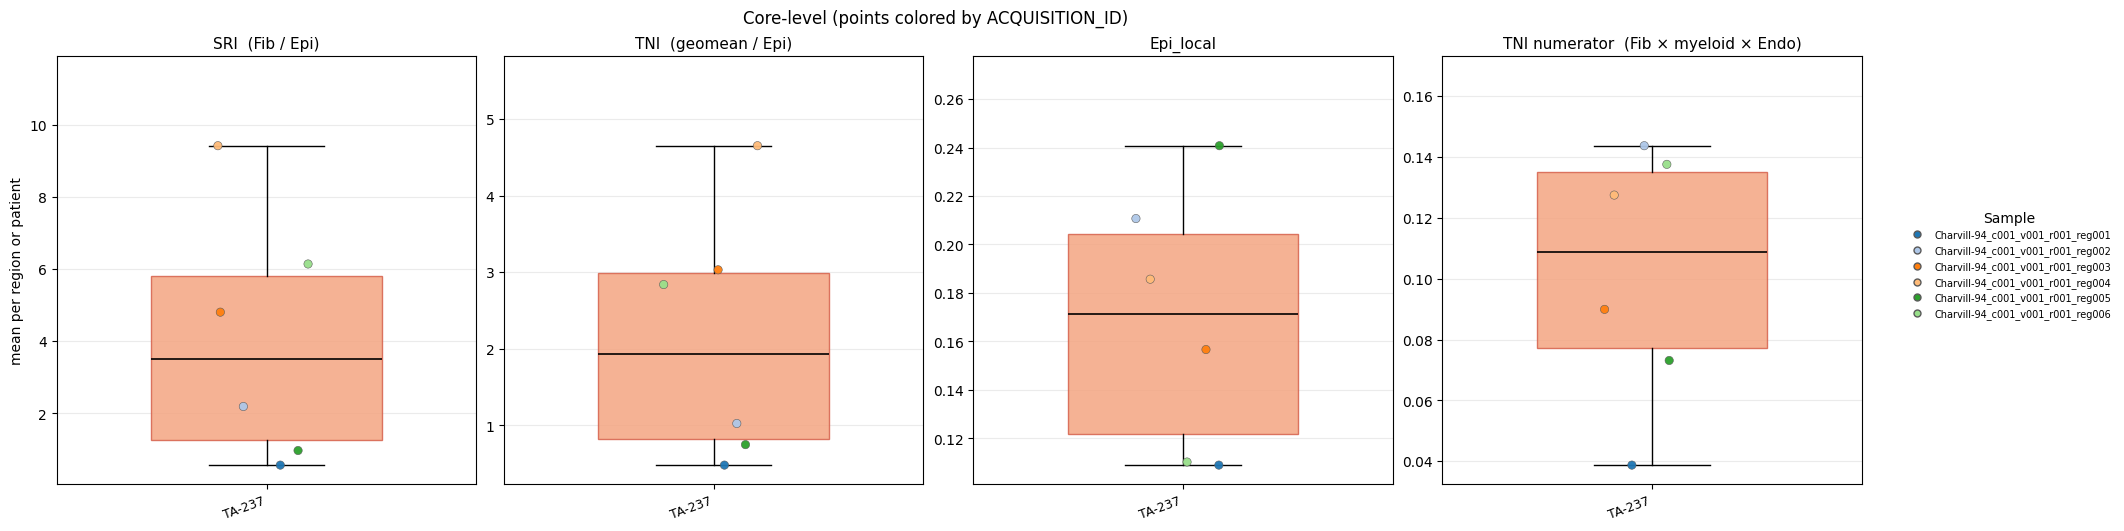

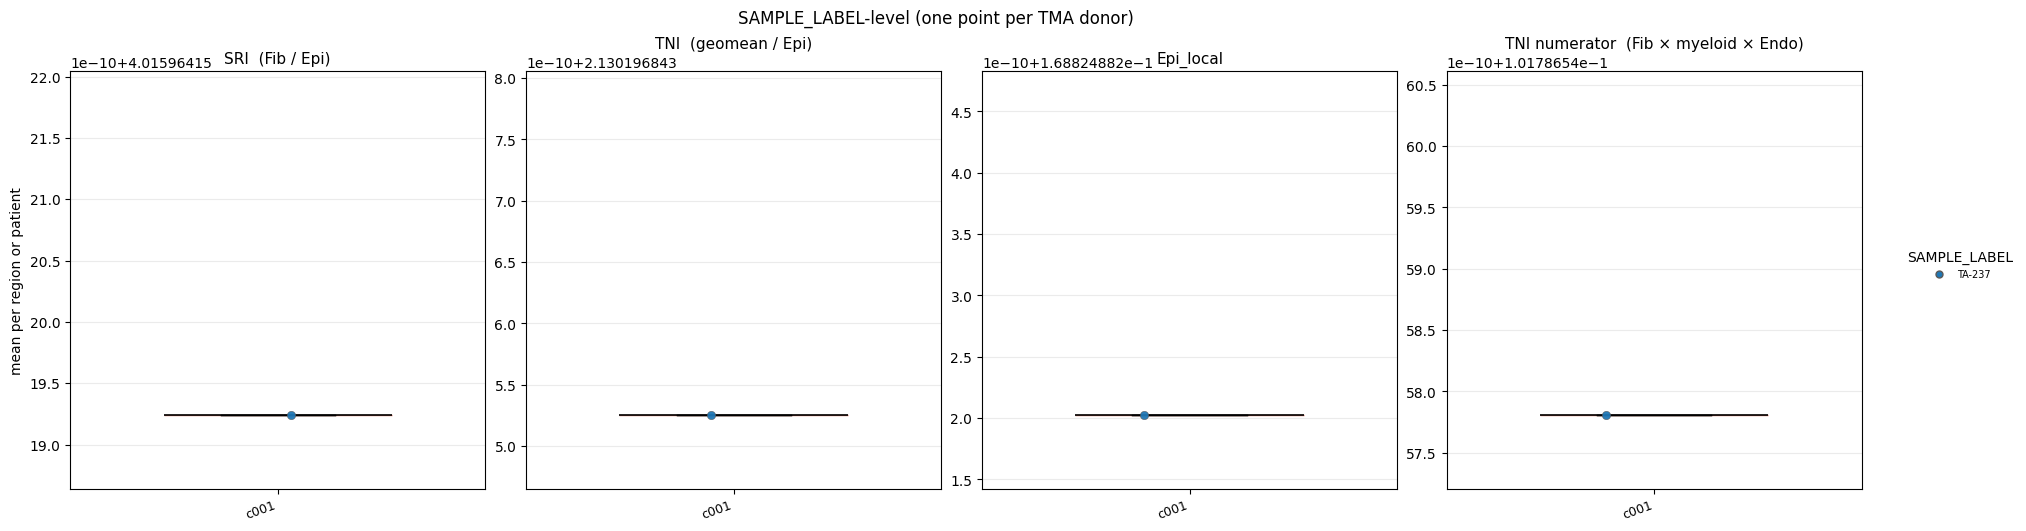

In [13]:
pdac_ni.plot_source_metric_grid(
    region_source, region_source_stats,
    sample_col="Sample", group_col="SAMPLE_LABEL",
    suptitle="Core-level (points colored by ACQUISITION_ID)",
)
pdac_ni.plot_source_metric_grid(
    patient_source, patient_source_stats,
    sample_col="SAMPLE_LABEL", group_col="coverslip",
    suptitle="SAMPLE_LABEL-level (one point per TMA donor)",
)
